In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
!pip install opencv-python-headless

In [4]:
from google.colab import files

uploaded = files.upload()

Saving 5e.jpeg to 5e.jpeg


In [7]:
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow

# Create output folder
os.makedirs("processed_images", exist_ok=True)

# Get uploaded image names
image_files = list(uploaded.keys())

print("Processing Images on CPU...\n")

for image_name in image_files:

    print("Processing:", image_name)

    # Read image
    img = cv2.imread(image_name)

    if img is None:
        print("Failed to load:", image_name)
        continue

    # Convert to grayscale on CPU
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur on CPU
    blur_img = cv2.GaussianBlur(gray_img, (5, 5), 1)

    # Edge Detection on CPU
    edges = cv2.Canny(blur_img, 100, 200)

    # Save output
    output_name = "processed_" + image_name

    cv2.imwrite(
        os.path.join("processed_images", output_name),
        edges
    )

    print("Saved:", output_name)

print("\nAll images processed successfully!")

Processing Images on CPU...

Processing: 5e.jpeg
Saved: processed_5e.jpeg

All images processed successfully!


Showing: processed_5e.jpeg


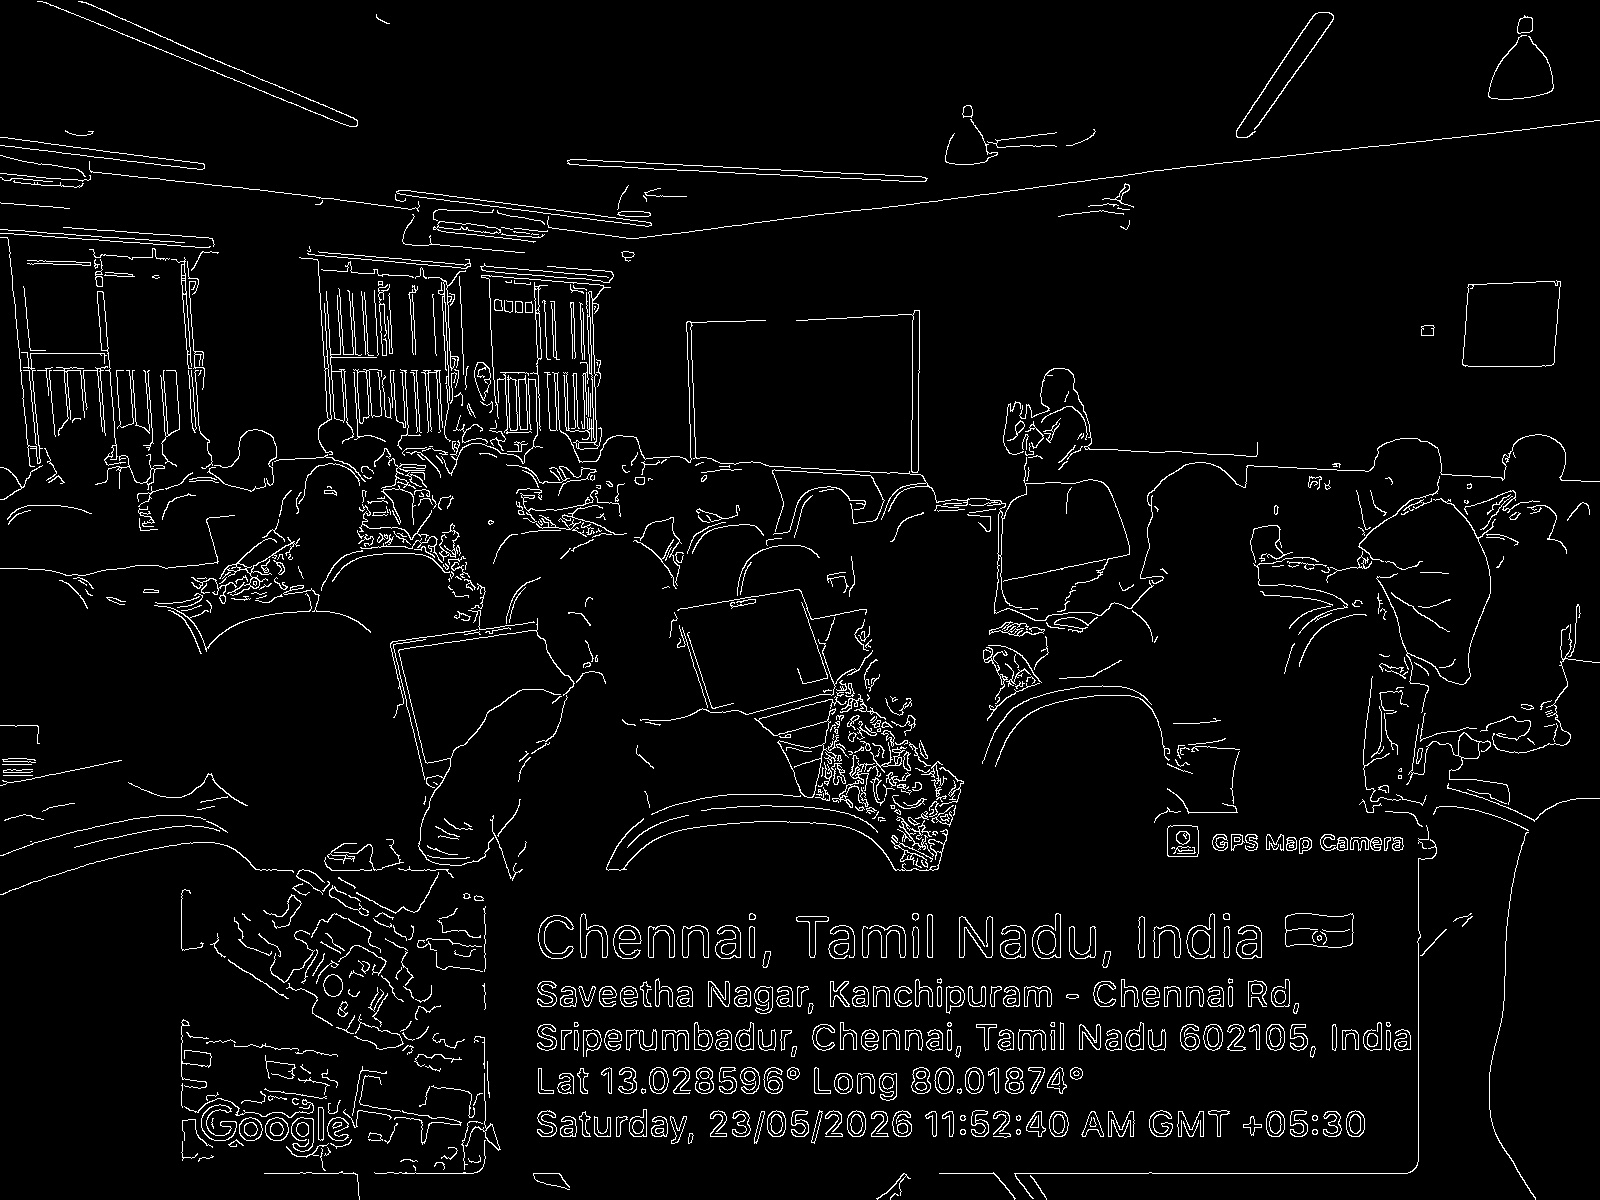

In [8]:
import os
from google.colab.patches import cv2_imshow

output_files = os.listdir("processed_images")

for file in output_files[:5]:

    print("Showing:", file)

    img = cv2.imread(
        os.path.join("processed_images", file),
        cv2.IMREAD_GRAYSCALE
    )

    cv2_imshow(img)

In [9]:
!zip -r processed_images.zip processed_images

  adding: processed_images/ (stored 0%)
  adding: processed_images/processed_5e.jpeg (deflated 11%)


In [10]:
from google.colab import files

files.download("processed_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>